# GO Fundamentals

This notebook analyses the fundamental supply–demand dynamics of Guarantees of Origin (GOs) within the AIB European Energy Certificate System (EECS). The source dataset is the AIB Activity Statistics, which records certificate lifecycle events — issuance, transfer, export, import, cancellation, expiry, and withdrawal — indexed by both **production date** $(t_{\text{prod}})$ and **transaction date** $(t_{\text{txn}})$.

In [174]:
import pandas as pd

path_1 = "/Users/kad/Library/CloudStorage/OneDrive-InCommoditiesAS/Data/GOs/GO_All_Statistics_1.csv"

df_1 = pd.read_csv(path_1, sep=",")

path_2 = "/Users/kad/Library/CloudStorage/OneDrive-InCommoditiesAS/Data/GOs/GO_All_Statistics_2.csv"

df_2 = pd.read_csv(path_2, sep=",")

df = pd.concat([df_1, df_2], ignore_index=True)

display(df)

,year_month_date,year,month_name,domain_name,energy_carrier,energy_source_name,energy_source_level1,energy_source_level2,production_technology_name,production_date_cancel,production_date_expire,production_date_issue,transaction_date_cancel,transaction_date_expire,transaction_date_export,transaction_date_import,transaction_date_issue,transaction_date_transfer,transaction_date_withdraw
0,2025-03-01,2025,March,PT - Portugal,EECS-Electricity,F01010101,Renewable,Renewable - Biomass,T050202,0,0,0,0,0,0,1134,0,0,0
1,2026-03-01,2026,March,CZ - Czech Republic,EECS-Electricity,F01030400,Renewable,Renewable - Biomass,T050500,0,0,0,1918,0,0,1918,0,0,0
2,2025-05-01,2025,May,FR - France,EECS-Electricity,F01010301,Renewable,Renewable - Biomass,T050301,5529,0,0,0,0,0,0,0,0,0
3,2023-03-01,2023,March,CZ - Czech Republic,EECS-Electricity,F01050100,Renewable,Renewable - Wind,T020000,59613,447,44798,92322,2238,27707,41757,44047,47886,0
4,2024-03-01,2024,March,FR - France,EECS-Electricity,F01030400,Renewable,Renewable - Biomass,T050502,0,0,0,2000,0,0,2000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114135,2022-12-01,2022,December,IT - Italy,EECS-Electricity,F01010101,Renewable,Renewable - Biomass,T050000,147307,0,128702,0,0,7254,263060,154040,10722,0
114136,2019-05-01,2019,May,NO - Norway,EECS-Electricity,F01050200,Renewable,Renewable - Hydro & Marine,T030000,2309808,40178,8019101,356688,817501,3432797,415589,7062114,984905,0
114137,2020-04-01,2020,April,AT - Austria,EECS-Electricity,F01030300,Renewable,Renewable - Biomass,T050501,0,0,0,357,0,0,0,0,0,0
114138,2022-02-01,2022,February,AT - Austria,EECS-Electricity,F01010300,Renewable,Renewable - Biomass,T050202,0,0,0,0,0,0,0,0,14626,0


The raw columns are restructured into a standardised format. Calendar dimensions (`year`, `month`) are extracted, classification columns (`country_code`, `energy_source_category`, `energy_source`) are normalised, and all volume fields are cast to numeric type. The final dataframe `go_df` serves as the basis for all subsequent analysis.

In [191]:
go_df = df.copy()

# Only consider energy carrier electricity for now
go_df = go_df[go_df['energy_carrier'].str.contains('Electricity')]

# Calendar columns
go_df["month"] = go_df["year_month_date"].str.split("-").str[1].astype(int)
go_df["year"] = go_df["year"].astype(int)

go_df = go_df.drop(columns=["year_month_date", "month_name"])

# Classification columns
go_df['country_code'] = go_df['domain_name'].str.split(' ').str[0].astype(str)
go_df['energy_source_category'] = go_df['energy_source_level1'].astype(str)
go_df['energy_source'] = go_df['energy_source_level2'].str.split(' ').str[-1].astype(str)

go_df = go_df.drop(columns=['domain_name',  'energy_carrier', 'energy_source_name', 'energy_source_level1', 'energy_source_level2', 'production_technology_name'])

# Columns reordering
go_df = go_df[['year', 'month', 'country_code', 'energy_source_category', 'energy_source'] + go_df.columns[1:11].tolist()]

# Remove incomplete last month data
go_df = go_df[(go_df['year'] >= 2020) & ~((go_df['year'] == 2026) & (go_df['month'] == 4))]

display(go_df)

,year,month,country_code,energy_source_category,energy_source,production_date_cancel,production_date_expire,production_date_issue,transaction_date_cancel,transaction_date_expire,transaction_date_export,transaction_date_import,transaction_date_issue,transaction_date_transfer,transaction_date_withdraw
0,2025,3,PT,Renewable,Biomass,0,0,0,0,0,0,1134,0,0,0
1,2026,3,CZ,Renewable,Biomass,0,0,0,1918,0,0,1918,0,0,0
2,2025,5,FR,Renewable,Biomass,5529,0,0,0,0,0,0,0,0,0
3,2023,3,CZ,Renewable,Wind,59613,447,44798,92322,2238,27707,41757,44047,47886,0
4,2024,3,FR,Renewable,Biomass,0,0,0,2000,0,0,2000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114133,2021,11,DK,Renewable,Marine,46596,0,190,0,4673,1024,11840,233,0,0
114135,2022,12,IT,Renewable,Biomass,147307,0,128702,0,0,7254,263060,154040,10722,0
114137,2020,4,AT,Renewable,Biomass,0,0,0,357,0,0,0,0,0,0
114138,2022,2,AT,Renewable,Biomass,0,0,0,0,0,0,0,0,14626,0


# 1. Supply of Guarantees of Origin

Supply is measured by the volume of GOs **issued** within the system. Per AIB definitions:
- `production_date_issue`: number of GOs issued for electricity produced in a given month $(t_{\text{prod}})$.
- `transaction_date_issue`: number of GOs issued during a given month $(t_{\text{txn}})$, regardless of production date.

Let $S(t)$ denote aggregate supply at time $t$. We define:

$$S(t) = \sum_{c \in \mathcal{C}} \sum_{s \in \mathcal{S}} \text{issue}(c, s, t)$$

where $\mathcal{C}$ is the set of countries and $\mathcal{S}$ is the set of energy sources. We examine both the temporal evolution and the country-level decomposition of issuance.

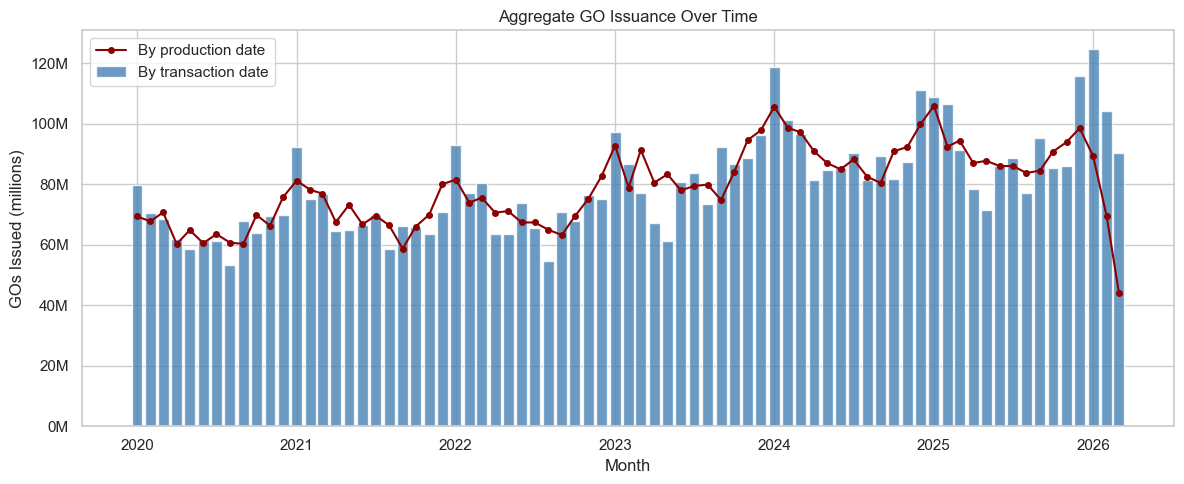

In [192]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")

# Aggregate monthly issuance (transaction date)
supply_monthly = go_df.groupby(['year', 'month'])[['transaction_date_issue', 'production_date_issue']].sum().reset_index()
supply_monthly['period'] = pd.to_datetime(supply_monthly[['year', 'month']].assign(day=1))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(supply_monthly['period'], supply_monthly['transaction_date_issue'] / 1e6, width=25, color='steelblue', alpha=0.8, label='By transaction date')
ax.plot(supply_monthly['period'], supply_monthly['production_date_issue'] / 1e6, color='darkred', marker='o', markersize=4, label='By production date')
ax.set_xlabel('Month')
ax.set_ylabel('GOs Issued (millions)')
ax.set_title('Aggregate GO Issuance Over Time')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))
plt.tight_layout()
plt.show()

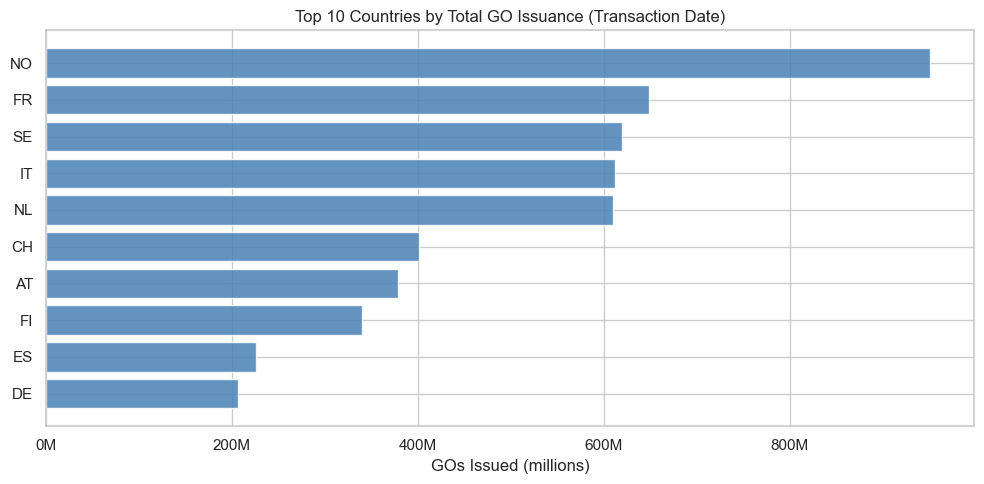

In [193]:
# Issuance by country (top 10 by total transaction_date_issue)
supply_country = go_df.groupby('country_code')['transaction_date_issue'].sum().sort_values(ascending=False)
top_countries = supply_country.head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_countries.index[::-1], top_countries.values[::-1] / 1e6, color='steelblue', alpha=0.85)
ax.set_xlabel('GOs Issued (millions)')
ax.set_title('Top 10 Countries by Total GO Issuance (Transaction Date)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))
plt.tight_layout()
plt.show()

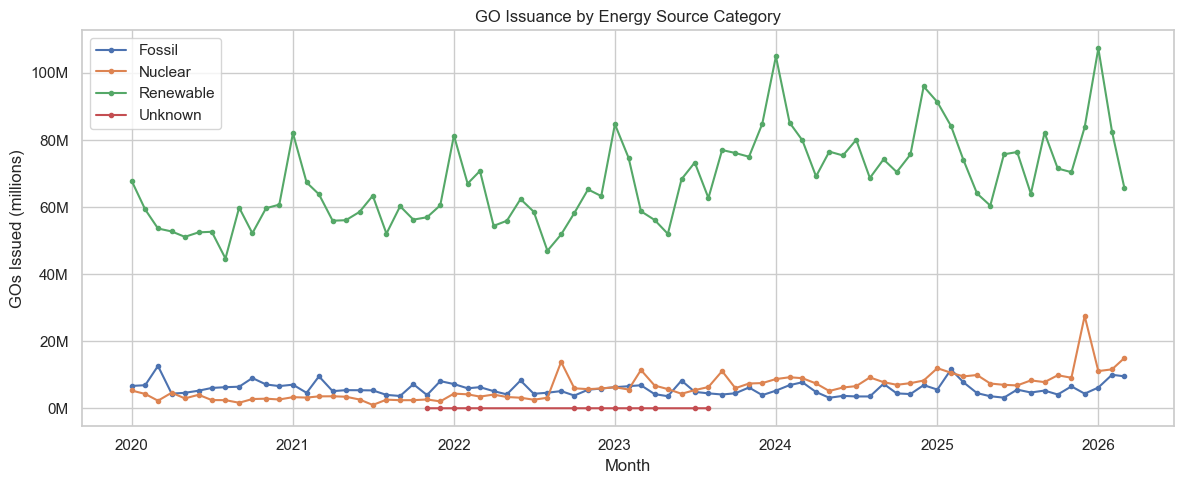

In [194]:
# Issuance by energy source category over time
supply_by_source = go_df.groupby(['year', 'month', 'energy_source_category'])['transaction_date_issue'].sum().reset_index()
supply_by_source['period'] = pd.to_datetime(supply_by_source[['year', 'month']].assign(day=1))

fig, ax = plt.subplots(figsize=(12, 5))
for cat, grp in supply_by_source.groupby('energy_source_category'):
    ax.plot(grp['period'], grp['transaction_date_issue'] / 1e6, marker='o', markersize=3, label=cat)
ax.set_xlabel('Month')
ax.set_ylabel('GOs Issued (millions)')
ax.set_title('GO Issuance by Energy Source Category')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))
plt.tight_layout()
plt.show()

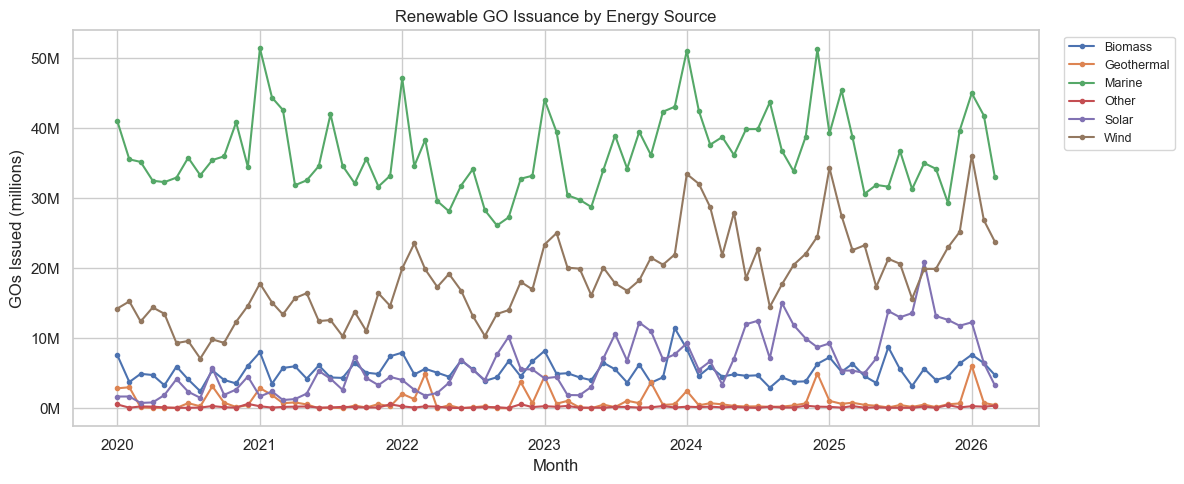

In [195]:
# Renewable issuance by energy source subcategory over time
supply_renewable = go_df[go_df['energy_source_category'] == 'Renewable'].groupby(
    ['year', 'month', 'energy_source'])['transaction_date_issue'].sum().reset_index()
supply_renewable['period'] = pd.to_datetime(supply_renewable[['year', 'month']].assign(day=1))

fig, ax = plt.subplots(figsize=(12, 5))
for source, grp in supply_renewable.groupby('energy_source'):
    ax.plot(grp['period'], grp['transaction_date_issue'] / 1e6, marker='o', markersize=3, label=source)
ax.set_xlabel('Month')
ax.set_ylabel('GOs Issued (millions)')
ax.set_title('Renewable GO Issuance by Energy Source')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))
plt.tight_layout()
plt.show()

# 2. Demand for Guarantees of Origin

Demand is measured by the volume of GOs **cancelled**. Cancellation renders a GO non-transferrable and represents its final use — typically by a supplier disclosing the origin of electricity to an end consumer. Per AIB:
- `transaction_date_cancel`: GOs cancelled during month $t$.
- `production_date_cancel`: GOs cancelled that relate to electricity produced in month $t$.

Additionally, **expiry** (`transaction_date_expire`, `production_date_expire`) removes GOs that have exceeded their 12-month validity. While expiry is involuntary, it represents demand that was *not* exercised and contributes to the removal of supply.

Let $D(t)$ denote total demand (cancellations) at time $t$:

$$D(t) = \sum_{c \in \mathcal{C}} \sum_{s \in \mathcal{S}} \text{cancel}(c, s, t)$$

We analyse both active cancellation and expiry volumes.

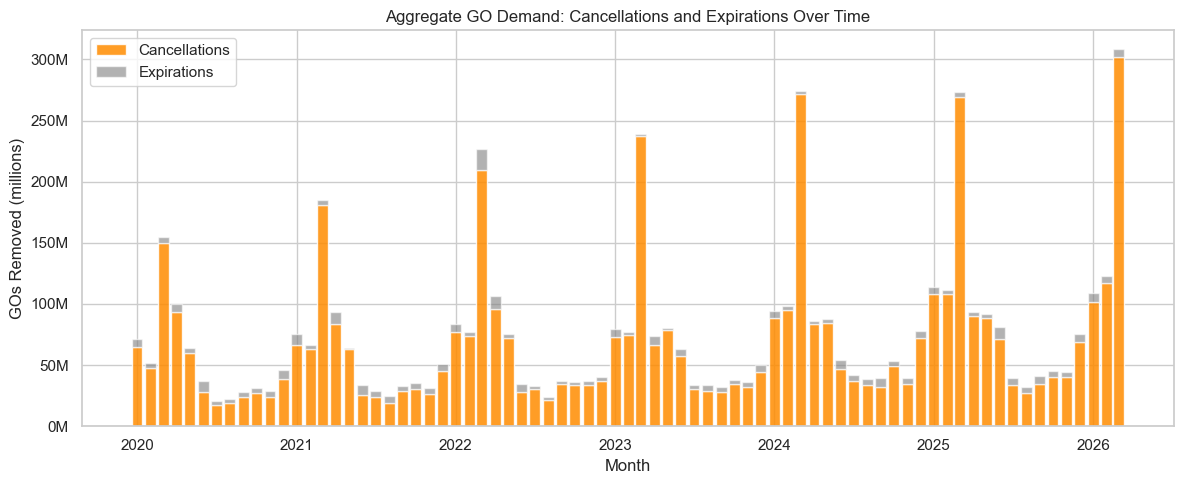

In [196]:
# Aggregate monthly cancellations and expirations (transaction date)
demand_monthly = go_df.groupby(['year', 'month'])[['transaction_date_cancel', 'transaction_date_expire']].sum().reset_index()
demand_monthly['period'] = pd.to_datetime(demand_monthly[['year', 'month']].assign(day=1))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(demand_monthly['period'], demand_monthly['transaction_date_cancel'] / 1e6, width=25, color='darkorange', alpha=0.85, label='Cancellations')
ax.bar(demand_monthly['period'], demand_monthly['transaction_date_expire'] / 1e6, width=25, bottom=demand_monthly['transaction_date_cancel'] / 1e6, color='grey', alpha=0.6, label='Expirations')
ax.set_xlabel('Month')
ax.set_ylabel('GOs Removed (millions)')
ax.set_title('Aggregate GO Demand: Cancellations and Expirations Over Time')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))
plt.tight_layout()
plt.show()

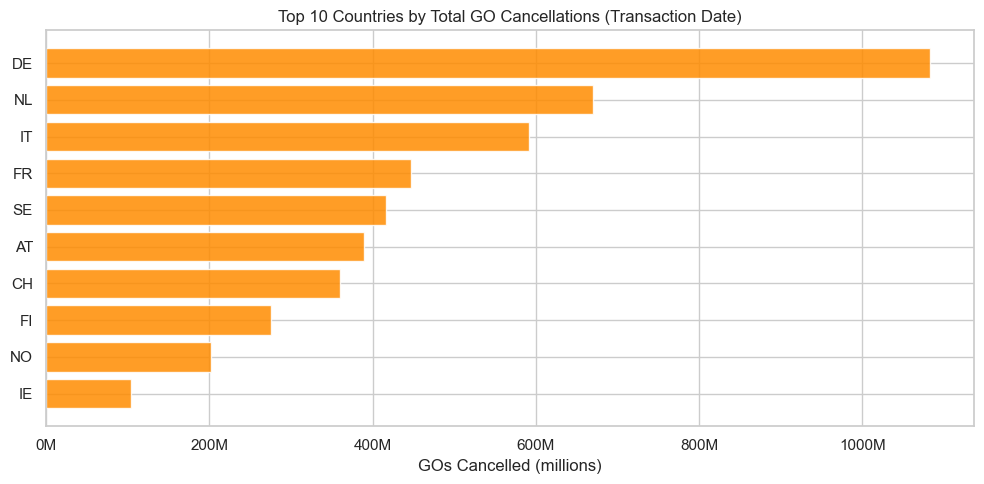

In [197]:
# Cancellations by country (top 10)
demand_country = go_df.groupby('country_code')['transaction_date_cancel'].sum().sort_values(ascending=False)
top_demand = demand_country.head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_demand.index[::-1], top_demand.values[::-1] / 1e6, color='darkorange', alpha=0.85)
ax.set_xlabel('GOs Cancelled (millions)')
ax.set_title('Top 10 Countries by Total GO Cancellations (Transaction Date)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))
plt.tight_layout()
plt.show()

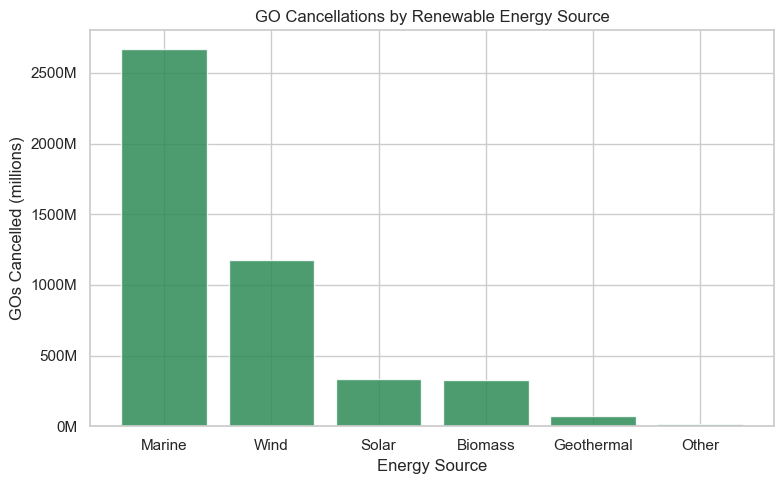

In [198]:
# Demand by energy source (renewable breakdown)
demand_renewable = go_df[go_df['energy_source_category'] == 'Renewable'].groupby('energy_source')['transaction_date_cancel'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(demand_renewable.index, demand_renewable.values / 1e6, color='seagreen', alpha=0.85)
ax.set_xlabel('Energy Source')
ax.set_ylabel('GOs Cancelled (millions)')
ax.set_title('GO Cancellations by Renewable Energy Source')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))
plt.tight_layout()
plt.show()

# 3. Inventory of Guarantees of Origin

The GO inventory (or outstanding stock) at the end of period $t$ is the cumulative balance of issuance minus all forms of removal. Using transaction-date statistics:

$$I(t) = \sum_{\tau=0}^{t} \Big[ \text{issue}(\tau) - \text{cancel}(\tau) - \text{expire}(\tau) - \text{withdraw}(\tau) \Big]$$

Note that transfers, exports, and imports are internal redistributions and do not alter aggregate inventory (they are zero-sum across the system). We compute the running inventory both at the aggregate level and per country.

At the country level, exports decrease and imports increase local inventory:

$$I_c(t) = \sum_{\tau=0}^{t} \Big[ \text{issue}_c(\tau) + \text{import}_c(\tau) - \text{export}_c(\tau) - \text{cancel}_c(\tau) - \text{expire}_c(\tau) - \text{withdraw}_c(\tau) \Big]$$

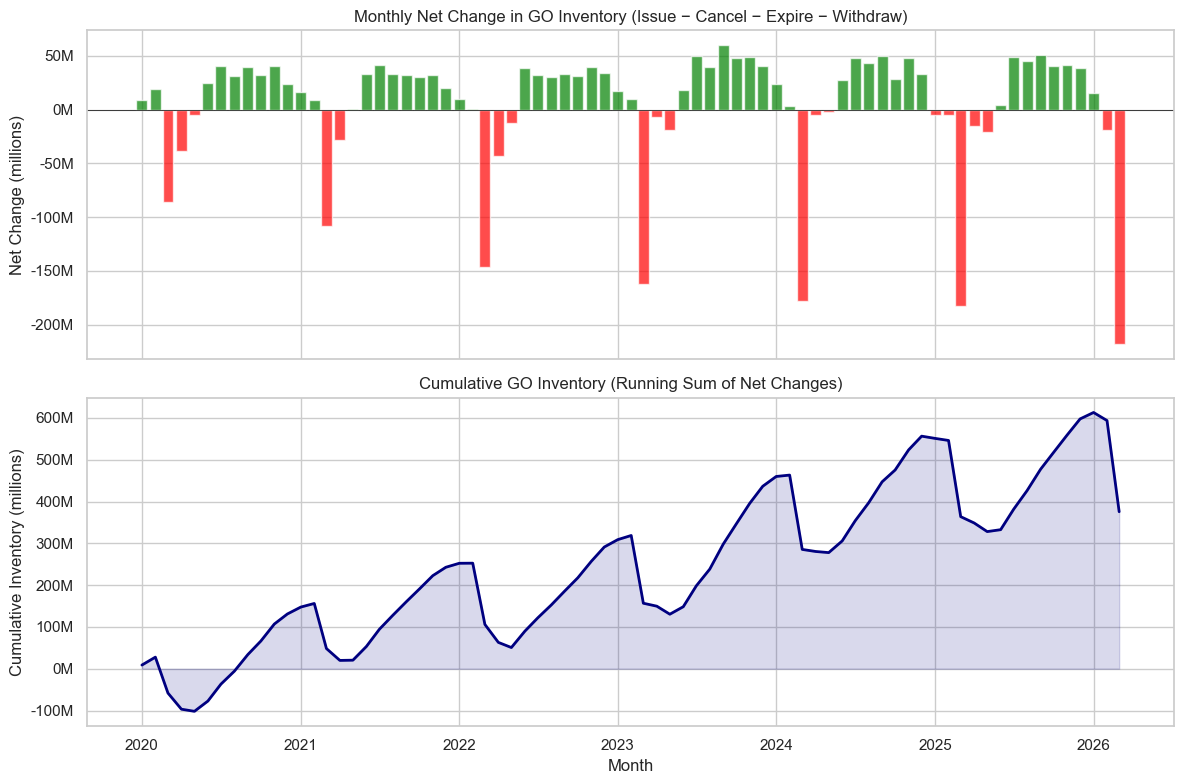

In [199]:
# Aggregate inventory: cumulative issuance minus removals
inventory_monthly = go_df.groupby(['year', 'month']).agg(
    issued=('transaction_date_issue', 'sum'),
    cancelled=('transaction_date_cancel', 'sum'),
    expired=('transaction_date_expire', 'sum'),
    withdrawn=('transaction_date_withdraw', 'sum')
).reset_index()
inventory_monthly['period'] = pd.to_datetime(inventory_monthly[['year', 'month']].assign(day=1))
inventory_monthly = inventory_monthly.sort_values('period')

inventory_monthly['net_change'] = inventory_monthly['issued'] - inventory_monthly['cancelled'] - inventory_monthly['expired'] - inventory_monthly['withdrawn']
inventory_monthly['inventory'] = inventory_monthly['net_change'].cumsum()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Net monthly change
colors = ['green' if x >= 0 else 'red' for x in inventory_monthly['net_change']]
axes[0].bar(inventory_monthly['period'], inventory_monthly['net_change'] / 1e6, width=25, color=colors, alpha=0.7)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_ylabel('Net Change (millions)')
axes[0].set_title('Monthly Net Change in GO Inventory (Issue − Cancel − Expire − Withdraw)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))

# Cumulative inventory
axes[1].plot(inventory_monthly['period'], inventory_monthly['inventory'] / 1e6, color='navy', linewidth=2)
axes[1].fill_between(inventory_monthly['period'], 0, inventory_monthly['inventory'] / 1e6, alpha=0.15, color='navy')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Cumulative Inventory (millions)')
axes[1].set_title('Cumulative GO Inventory (Running Sum of Net Changes)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))

plt.tight_layout()
plt.show()

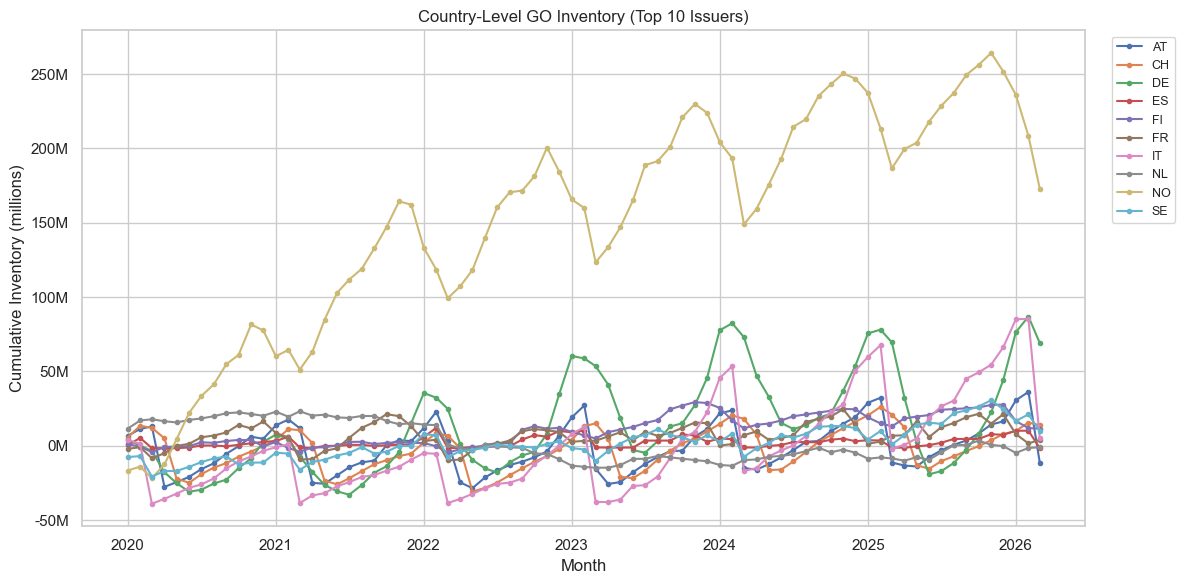

In [200]:
# Country-level inventory (top 10 issuers)
top10_codes = supply_country.head(10).index.tolist()
inv_country = go_df[go_df['country_code'].isin(top10_codes)].groupby(['year', 'month', 'country_code']).agg(
    issued=('transaction_date_issue', 'sum'),
    imported=('transaction_date_import', 'sum'),
    exported=('transaction_date_export', 'sum'),
    cancelled=('transaction_date_cancel', 'sum'),
    expired=('transaction_date_expire', 'sum'),
    withdrawn=('transaction_date_withdraw', 'sum')
).reset_index()
inv_country['period'] = pd.to_datetime(inv_country[['year', 'month']].assign(day=1))
inv_country = inv_country.sort_values(['country_code', 'period'])

inv_country['net_change'] = (inv_country['issued'] + inv_country['imported']
                             - inv_country['exported'] - inv_country['cancelled']
                             - inv_country['expired'] - inv_country['withdrawn'])
inv_country['inventory'] = inv_country.groupby('country_code')['net_change'].cumsum()

fig, ax = plt.subplots(figsize=(12, 6))
for code, grp in inv_country.groupby('country_code'):
    ax.plot(grp['period'], grp['inventory'] / 1e6, marker='o', markersize=3, label=code)
ax.set_xlabel('Month')
ax.set_ylabel('Cumulative Inventory (millions)')
ax.set_title('Country-Level GO Inventory (Top 10 Issuers)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))
plt.tight_layout()
plt.show()

## 3.1 Estimating Starting Inventory $I_0$

The cumulative balance computed above assumes $I(0) = 0$, which is incorrect — GOs issued before January 2020 were still in circulation at the dataset start. We estimate the initial inventory $I_0$ via two independent methods.

**Method 1 — Non-negativity constraint.** The true inventory $I(t) = I_0 + \Delta(t) \geq 0$ for all $t$, where $\Delta(t) = \sum_{\tau=1}^{t} \text{net\_change}(\tau)$. Therefore:

$$I_0 \geq -\min_{t} \Delta(t)$$

This provides a **lower bound** on starting inventory: the minimum value consistent with non-negative stock at every point.

**Method 2 — Production vs. transaction date divergence.** The dataset provides both a *production-date* and a *transaction-date* view. Cancellations and expirations recorded by transaction date that exceed those recorded by production date must relate to certificates for **pre-2020 production** — i.e., certificates that were in the starting inventory:

$$\hat{I}_0^{\text{removals}} = \sum_{t \in \mathcal{T}} \big[\text{txn\_cancel}(t) - \text{prod\_cancel}(t)\big] + \sum_{t \in \mathcal{T}} \big[\text{txn\_expire}(t) - \text{prod\_expire}(t)\big]$$

Conversely, issuances by transaction date exceeding those by production date represent **late issuance** of pre-2020 production certificates entering the system during the observation window. These partially offset the starting stock estimate since they were not yet issued at $t=0$:

$$\hat{I}_0 = \hat{I}_0^{\text{removals}} - \big[\sum \text{txn\_issue}(t) - \sum \text{prod\_issue}(t)\big]^+$$

In [201]:
# Method 1: Non-negativity constraint (aggregate)
# I_0 >= -min(cumulative net change)
min_cumulative = inventory_monthly['inventory'].min()
I0_lower_bound = max(0, -min_cumulative)

print("=== Method 1: Non-Negativity Constraint (Aggregate) ===")
print(f"Minimum cumulative balance (assuming I_0=0): {min_cumulative:,.0f}")
print(f"Lower bound on starting inventory I_0: {I0_lower_bound:,.0f} ({I0_lower_bound/1e6:.1f}M GOs)")
print()

# Method 2: Production vs. transaction date divergence (aggregate)
totals = go_df[['production_date_cancel', 'production_date_expire', 'production_date_issue',
                'transaction_date_cancel', 'transaction_date_expire', 'transaction_date_issue']].sum()

excess_cancel = totals['transaction_date_cancel'] - totals['production_date_cancel']
excess_expire = totals['transaction_date_expire'] - totals['production_date_expire']
excess_issue = totals['transaction_date_issue'] - totals['production_date_issue']

I0_removals = excess_cancel + excess_expire
I0_divergence = I0_removals - max(0, excess_issue)

print("=== Method 2: Production vs. Transaction Date Divergence (Aggregate) ===")
print(f"Excess cancellations (txn − prod):  {excess_cancel:,.0f}")
print(f"Excess expirations  (txn − prod):  {excess_expire:,.0f}")
print(f"Excess issuances    (txn − prod):  {excess_issue:,.0f} (late issuance of pre-2020 production)")
print()
print(f"Estimated pre-2020 removals:        {I0_removals:,.0f} ({I0_removals/1e6:.1f}M)")
print(f"Minus late issuance offset:         {max(0, excess_issue):,.0f}")
print(f"Estimated starting inventory I_0:   {I0_divergence:,.0f} ({I0_divergence/1e6:.1f}M GOs)")
print()
print("=== Summary ===")
print(f"Method 1 (lower bound):  {I0_lower_bound/1e6:.1f}M GOs")
print(f"Method 2 (divergence):   {I0_divergence/1e6:.1f}M GOs")

=== Method 1: Non-Negativity Constraint (Aggregate) ===
Minimum cumulative balance (assuming I_0=0): -101,727,030
Lower bound on starting inventory I_0: 101,727,030 (101.7M GOs)

=== Method 2: Production vs. Transaction Date Divergence (Aggregate) ===
Excess cancellations (txn − prod):  289,572,145
Excess expirations  (txn − prod):  76,615,288
Excess issuances    (txn − prod):  80,439,893 (late issuance of pre-2020 production)

Estimated pre-2020 removals:        366,187,433 (366.2M)
Minus late issuance offset:         80,439,893
Estimated starting inventory I_0:   285,747,540 (285.7M GOs)

=== Summary ===
Method 1 (lower bound):  101.7M GOs
Method 2 (divergence):   285.7M GOs


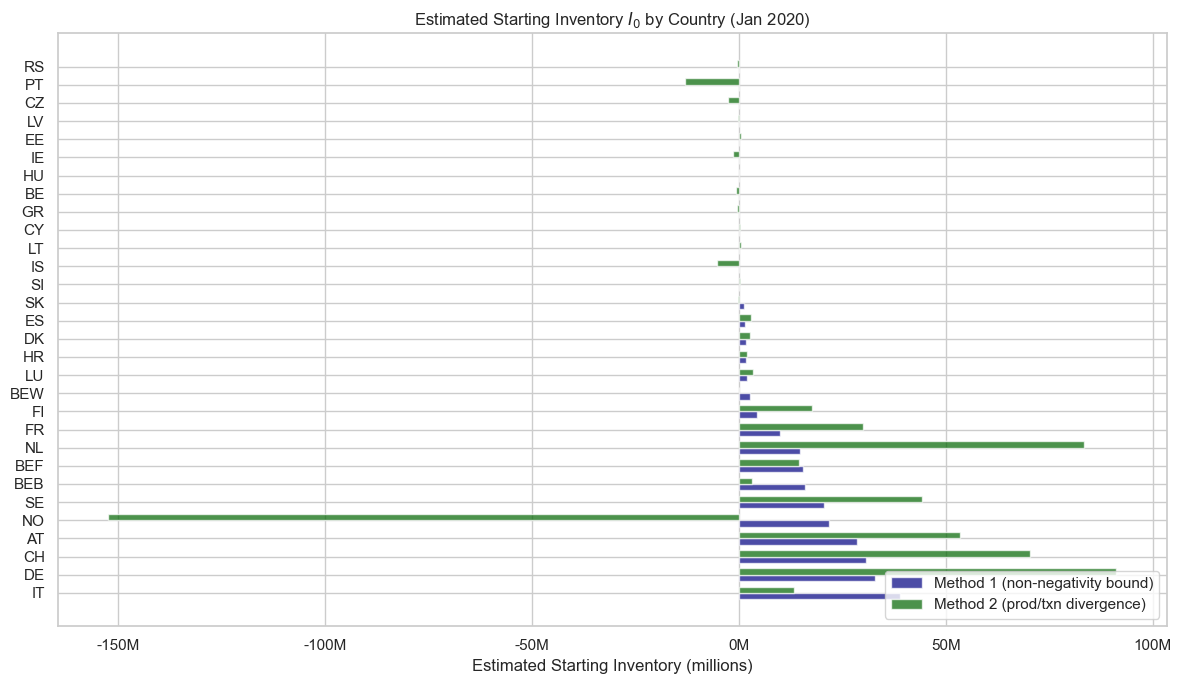


Country-level I_0 estimates (top 15 by Method 1):
Country    Method 1 (M) Method 2 (M)
------------------------------------
IT                 39.0         13.4
DE                 32.9         91.3
CH                 30.8         70.3
AT                 28.5         53.5
NO                 21.8       -152.3
SE                 20.7         44.2
BEB                16.1          3.3
BEF                15.6         14.5
NL                 14.8         83.5
FR                  9.9         30.1
FI                  4.5         17.7
BEW                 2.8         -0.0
LU                  2.1          3.3
HR                  1.7          2.0
DK                  1.6          2.6


In [202]:
# Country-level starting inventory estimation (both methods)
# Method 1: Non-negativity per country
country_inv = go_df.groupby(['year', 'month', 'country_code']).agg(
    txn_issue=('transaction_date_issue', 'sum'),
    txn_import=('transaction_date_import', 'sum'),
    txn_export=('transaction_date_export', 'sum'),
    txn_cancel=('transaction_date_cancel', 'sum'),
    txn_expire=('transaction_date_expire', 'sum'),
    txn_withdraw=('transaction_date_withdraw', 'sum'),
    prod_cancel=('production_date_cancel', 'sum'),
    prod_expire=('production_date_expire', 'sum'),
    prod_issue=('production_date_issue', 'sum')
).reset_index()
country_inv['period'] = pd.to_datetime(country_inv[['year', 'month']].assign(day=1))
country_inv = country_inv.sort_values(['country_code', 'period'])

country_inv['net_change'] = (country_inv['txn_issue'] + country_inv['txn_import']
                             - country_inv['txn_export'] - country_inv['txn_cancel']
                             - country_inv['txn_expire'] - country_inv['txn_withdraw'])
country_inv['cumulative'] = country_inv.groupby('country_code')['net_change'].cumsum()

# Method 1 per country
method1 = country_inv.groupby('country_code')['cumulative'].min().reset_index()
method1.columns = ['country_code', 'min_cumulative']
method1['I0_method1'] = method1['min_cumulative'].apply(lambda x: max(0, -x))

# Method 2 per country
country_totals = go_df.groupby('country_code').agg(
    txn_cancel=('transaction_date_cancel', 'sum'),
    prod_cancel=('production_date_cancel', 'sum'),
    txn_expire=('transaction_date_expire', 'sum'),
    prod_expire=('production_date_expire', 'sum'),
    txn_issue=('transaction_date_issue', 'sum'),
    prod_issue=('production_date_issue', 'sum')
).reset_index()
country_totals['excess_cancel'] = country_totals['txn_cancel'] - country_totals['prod_cancel']
country_totals['excess_expire'] = country_totals['txn_expire'] - country_totals['prod_expire']
country_totals['excess_issue'] = country_totals['txn_issue'] - country_totals['prod_issue']
country_totals['I0_method2'] = (country_totals['excess_cancel'] + country_totals['excess_expire']
                                 - country_totals['excess_issue'].clip(lower=0))

# Merge and display
I0_estimates = method1[['country_code', 'I0_method1']].merge(
    country_totals[['country_code', 'I0_method2']], on='country_code')
I0_estimates = I0_estimates.sort_values('I0_method1', ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
x = range(len(I0_estimates))
width = 0.35
ax.barh([i - width/2 for i in x], I0_estimates['I0_method1'] / 1e6, height=width,
        color='navy', alpha=0.7, label='Method 1 (non-negativity bound)')
ax.barh([i + width/2 for i in x], I0_estimates['I0_method2'] / 1e6, height=width,
        color='darkgreen', alpha=0.7, label='Method 2 (prod/txn divergence)')
ax.set_yticks(x)
ax.set_yticklabels(I0_estimates['country_code'])
ax.set_xlabel('Estimated Starting Inventory (millions)')
ax.set_title('Estimated Starting Inventory $I_0$ by Country (Jan 2020)')
ax.legend(loc='lower right')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))
plt.tight_layout()
plt.show()

# Print table for top countries
print("\nCountry-level I_0 estimates (top 15 by Method 1):")
print(f"{'Country':<10} {'Method 1 (M)':>12} {'Method 2 (M)':>12}")
print("-" * 36)
for _, row in I0_estimates.head(15).iterrows():
    print(f"{row['country_code']:<10} {row['I0_method1']/1e6:>12.1f} {row['I0_method2']/1e6:>12.1f}")

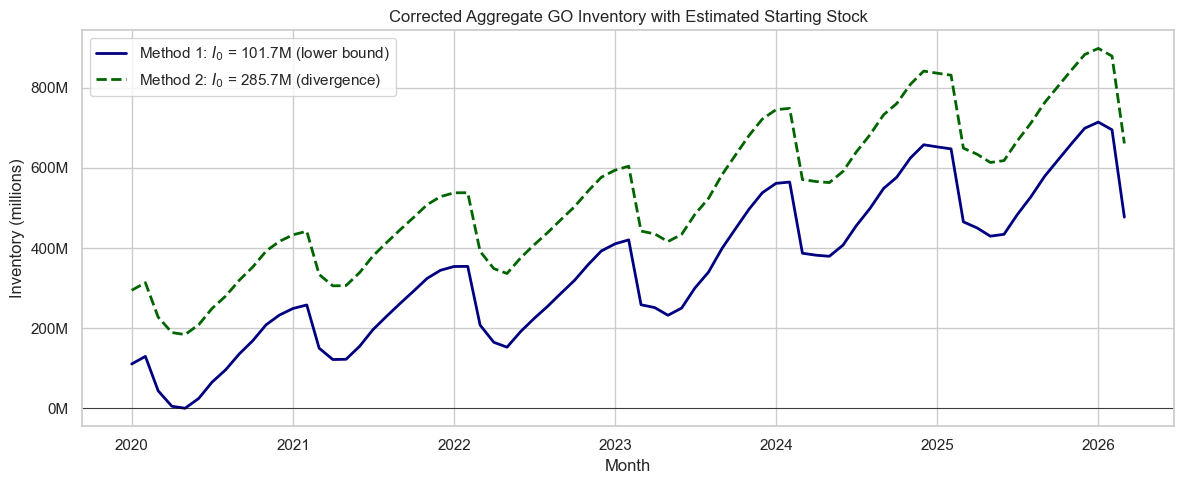

In [203]:
# Corrected aggregate inventory using both I_0 estimates
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(inventory_monthly['period'], (I0_lower_bound + inventory_monthly['inventory']) / 1e6,
        color='navy', linewidth=2, label=f'Method 1: $I_0$ = {I0_lower_bound/1e6:.1f}M (lower bound)')
ax.plot(inventory_monthly['period'], (I0_divergence + inventory_monthly['inventory']) / 1e6,
        color='darkgreen', linewidth=2, linestyle='--', label=f'Method 2: $I_0$ = {I0_divergence/1e6:.1f}M (divergence)')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Month')
ax.set_ylabel('Inventory (millions)')
ax.set_title('Corrected Aggregate GO Inventory with Estimated Starting Stock')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))
plt.tight_layout()
plt.show()

# 4. Flows of Guarantees of Origin

GO flows measure the redistribution of certificates across participants and borders. Three transaction types capture this:
- **Transfer** (`transaction_date_transfer`): intra-country/region movement between account holders.
- **Export** (`transaction_date_export`): cross-border outflow from country $c$.
- **Import** (`transaction_date_import`): cross-border inflow into country $c$.

For a given country $c$, the net cross-border position is:

$$\text{Net Flow}_c(t) = \text{import}_c(t) - \text{export}_c(t)$$

A positive net flow indicates the country is a net importer of GOs; negative indicates net exporter. At the aggregate level, $\sum_c \text{Net Flow}_c(t) = 0$ by construction (closed system).

We visualise both the aggregate flow volumes and the country-level net positions.

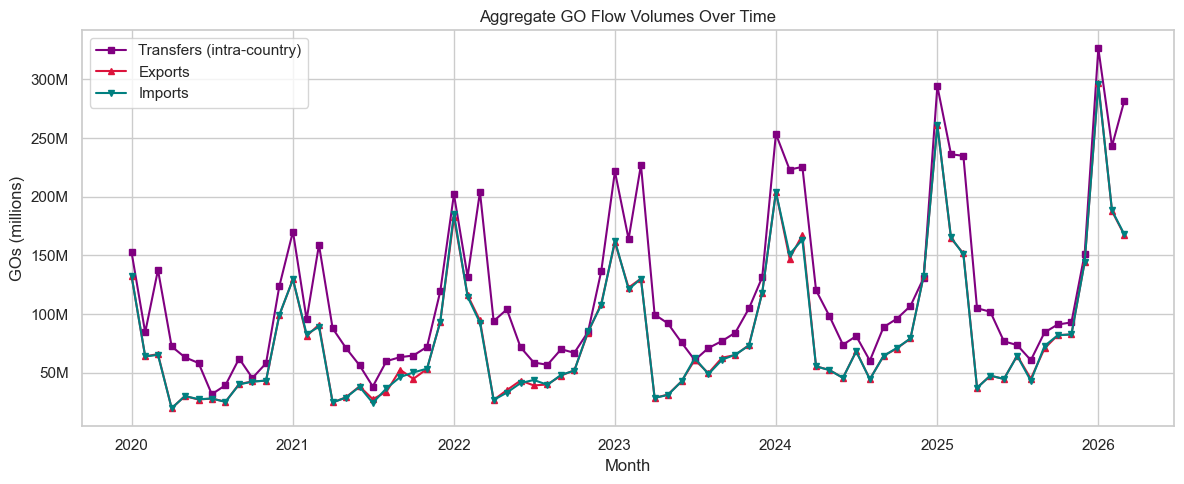

In [204]:
# Aggregate monthly flows
flows_monthly = go_df.groupby(['year', 'month'])[['transaction_date_export', 'transaction_date_import', 'transaction_date_transfer']].sum().reset_index()
flows_monthly['period'] = pd.to_datetime(flows_monthly[['year', 'month']].assign(day=1))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(flows_monthly['period'], flows_monthly['transaction_date_transfer'] / 1e6, color='purple', marker='s', markersize=4, label='Transfers (intra-country)')
ax.plot(flows_monthly['period'], flows_monthly['transaction_date_export'] / 1e6, color='crimson', marker='^', markersize=4, label='Exports')
ax.plot(flows_monthly['period'], flows_monthly['transaction_date_import'] / 1e6, color='teal', marker='v', markersize=4, label='Imports')
ax.set_xlabel('Month')
ax.set_ylabel('GOs (millions)')
ax.set_title('Aggregate GO Flow Volumes Over Time')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))
plt.tight_layout()
plt.show()

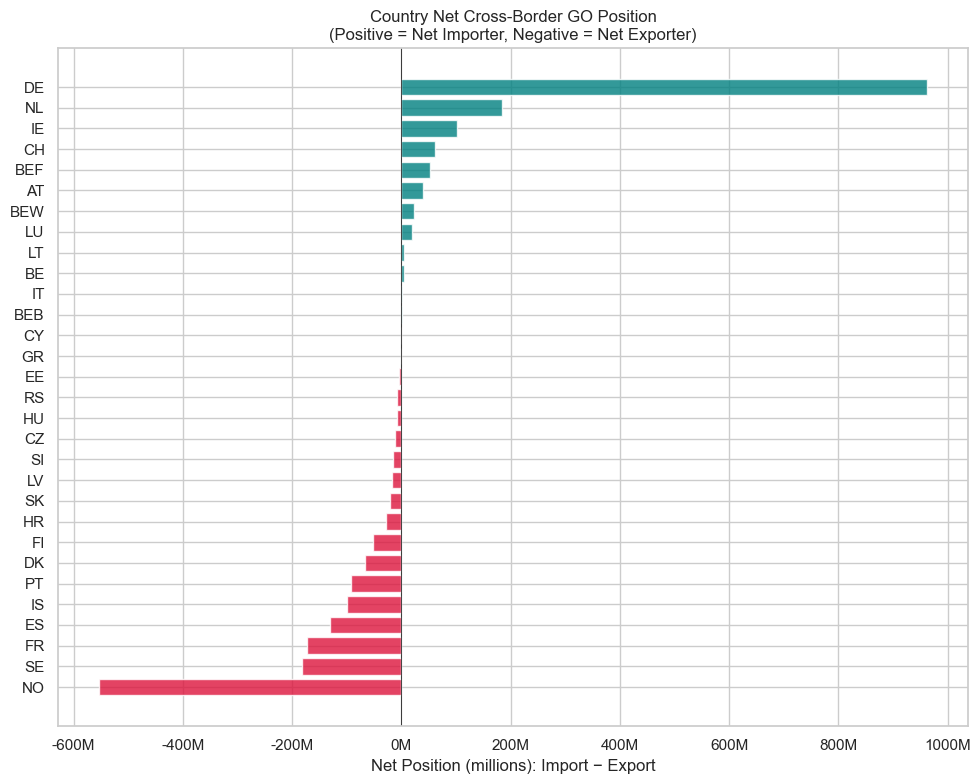

In [205]:
# Net cross-border position by country (total over all periods)
net_flows = go_df.groupby('country_code').agg(
    total_import=('transaction_date_import', 'sum'),
    total_export=('transaction_date_export', 'sum')
).reset_index()
net_flows['net_position'] = net_flows['total_import'] - net_flows['total_export']
net_flows = net_flows.sort_values('net_position', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['teal' if x >= 0 else 'crimson' for x in net_flows['net_position']]
ax.barh(net_flows['country_code'], net_flows['net_position'] / 1e6, color=colors, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Net Position (millions): Import − Export')
ax.set_title('Country Net Cross-Border GO Position\n(Positive = Net Importer, Negative = Net Exporter)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))
plt.tight_layout()
plt.show()

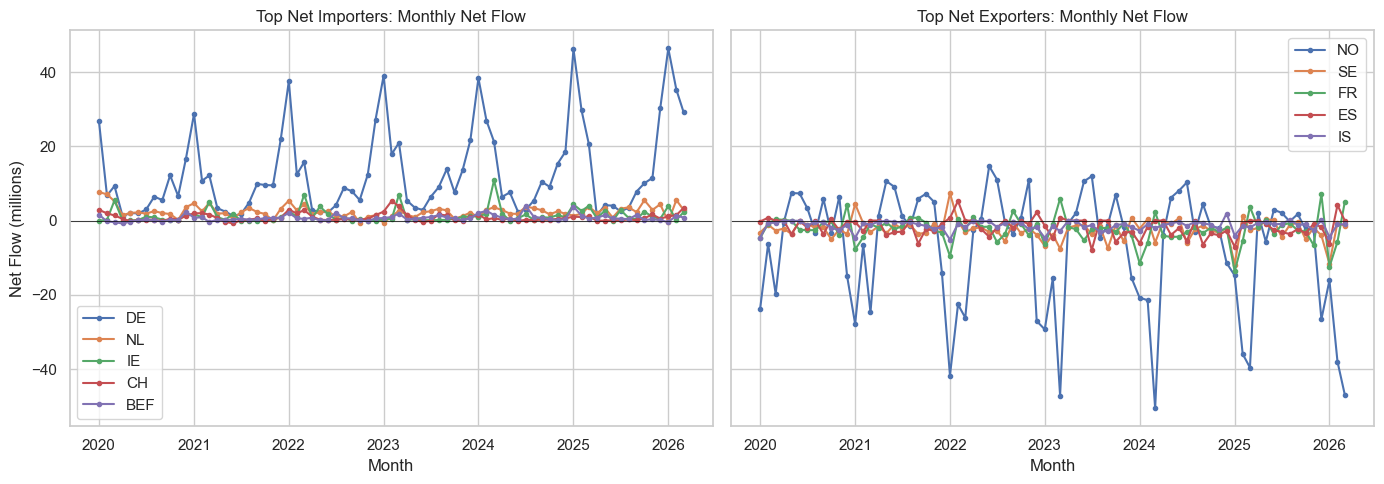

In [206]:
# Time evolution of net position for top net importers and exporters
top_importers = net_flows.nlargest(5, 'net_position')['country_code'].tolist()
top_exporters = net_flows.nsmallest(5, 'net_position')['country_code'].tolist()
focus_countries = top_importers + top_exporters

flow_ts = go_df[go_df['country_code'].isin(focus_countries)].groupby(['year', 'month', 'country_code']).agg(
    imported=('transaction_date_import', 'sum'),
    exported=('transaction_date_export', 'sum')
).reset_index()
flow_ts['period'] = pd.to_datetime(flow_ts[['year', 'month']].assign(day=1))
flow_ts['net_flow'] = flow_ts['imported'] - flow_ts['exported']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Net importers
for code in top_importers:
    grp = flow_ts[flow_ts['country_code'] == code]
    axes[0].plot(grp['period'], grp['net_flow'] / 1e6, marker='o', markersize=3, label=code)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('Top Net Importers: Monthly Net Flow')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Net Flow (millions)')
axes[0].legend()

# Net exporters
for code in top_exporters:
    grp = flow_ts[flow_ts['country_code'] == code]
    axes[1].plot(grp['period'], grp['net_flow'] / 1e6, marker='o', markersize=3, label=code)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('Top Net Exporters: Monthly Net Flow')
axes[1].set_xlabel('Month')
axes[1].legend()

plt.tight_layout()
plt.show()